# Notebook 04 — Generación de kymógrafos

Cuando el ruido por frame es tan alto que **ni siquiera un humano puede distinguir las vesículas individuales**, hay que cambiar de estrategia: pasar del **dominio espacial** (un frame a la vez) al **dominio espacio-tiempo** (kymógrafo).

## Qué es un kymógrafo

Una imagen 2D donde:

- **Eje X (horizontal)**: posición a lo largo del axón (1D, recorriendo la polilínea del ROI).
- **Eje Y (vertical)**: tiempo (un fila = un frame).

Cada vesícula deja una **traza** en el kymógrafo:

- **Línea diagonal** ↘ → vesícula moviéndose. La pendiente es la velocidad (px/frame).
- **Línea vertical** → vesícula estática.
- **Granulado sin estructura** → ruido aleatorio.

## Por qué destraba el problema

El kymógrafo **integra información temporal**. Una vesícula tenue cuyo SNR es ~1 en un frame se vuelve obvia como traza diagonal porque el ruido es aleatorio (no forma patrones coherentes) y la vesícula sí (se mueve consistentemente). El SNR efectivo escala como √T — para T=86 frames, **~9× mejor**.

## Ground truth disponible

El dataset incluye **217 kymógrafos `.tif`** generados manualmente por el lab con ImageJ. Vamos a comparar nuestra generación automática contra esa referencia para validar.


---

## Setup


In [7]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

sys.path.append(str(Path("..") / "src"))
from axonal_tracking.ets_reader import encontrar_ets, leer_header_ets, leer_video
from axonal_tracking import preprocesamiento as pp
from axonal_tracking import kimografo as km
from axonal_tracking import configuracion as cfg
from axonal_tracking.parametros import PIXEL_SIZE_UM, segundos_por_frame

# Configuracion compartida (escrita por el notebook 01).
config = cfg.cargar_configuracion()
VIDEO = config["video"]["ruta"]
ROI = config["video"]["roi"]
MODO = config["procesamiento"]["modo"]


# Kymograph del lab (ground truth). Dos layouts posibles en el dataset:
#   - Dataset "Ex": video y kymograph en el mismo folder.
#   - Dataset "Hipocampal": video en `Movies .../WTI/`, kymograph al lado del
#     ROI en `ROIS y Kymos/.../WT/`.
# Probamos ambas ubicaciones y nos quedamos con la primera que exista.
def _buscar_kymo_lab(video: Path, roi: Path) -> Path:
    nombre = f"Kymograph_{video.stem.replace('Movie_', '')}.tif"
    candidatos = [roi.parent / nombre, video.parent / nombre]
    for c in candidatos:
        if c.exists():
            return c
    return candidatos[0]  # preferido para mensajes aunque no exista


KYMO_LAB = _buscar_kymo_lab(VIDEO, ROI)

assert VIDEO.exists(), f"No se encontró: {VIDEO}"
assert ROI.exists(), f"No se encontró: {ROI}"
print(f"Video : {VIDEO.name}")
print(f"ROI   : {ROI.name}")
print(f'Kymo lab: {"si" if KYMO_LAB.exists() else "NO"} ({KYMO_LAB})')
print(
    f"Modo procesamiento: {MODO}, rango frames: {config['frames']['inicio']}:{config['frames']['fin']}"
)

Video : Movie_266.vsi
ROI   : 266.roi
Kymo lab: si (/Users/alejandrovalle/Desktop/Videos-Kymos-experimental data/Hipocampal neurons transport/N1-11 and 12-09-25/ROIS y Kymos/110925/WT/Kymograph_266.tif)
Modo procesamiento: configurable, rango frames: 0:None


---

## Cargamos el video completo

Para el kymógrafo necesitamos todos los frames (~470 MB para este video).


In [8]:
info = leer_header_ets(encontrar_ets(VIDEO))
video_full = leer_video(info)

# Aplicamos el rango configurado en `frames.inicio/fin`. El kymografo se hace
# sobre el video crudo uint16 — opera en intensidad bruta a lo largo del axon
# y no se beneficia del preprocesamiento RGB del notebook 01.
video = cfg.recortar_video(video_full, config)
print(
    f"Video: shape={video.shape}, dtype={video.dtype},"
    f" rango {config['frames']['inicio']}:{config['frames']['fin']},"
    f" {video.nbytes/1e6:.0f} MB"
)

Video: shape=(111, 2048, 2048), dtype=uint16, rango 0:None, 931 MB


---

## Generamos el kymógrafo

Dos pasos clave de la generación:

1. **Interpolamos la polilínea del ROI**: el `.roi` del lab tiene vértices cada 10–20 px. Para un kymógrafo necesitamos un punto por columna, así que interpolamos linealmente para tener puntos cada 1 px de arc-length.

2. **Para cada frame**, recorremos la polilínea muestreando una **banda perpendicular** al eje del axón (de ±3 px) y tomamos el **máximo** (mejor para partículas brillantes que un promedio).

Parámetros que podés tunear:

- `paso_px`: resolución espacial (default 1 px = máxima).
- `ancho_perpendicular`: ancho de la banda perpendicular (default 3 px = banda de 7 px).
- `metodo`: `"max"` para partículas brillantes, `"mean"` para señales difusas.


In [9]:
res = km.generar_kimografo(
    video,
    ROI,
    paso_px=1.0,
    ancho_perpendicular=3,
    metodo="max",
)

kymo = res["kimografo"]
print(
    f"Kymografo:  shape={kymo.shape} (T={kymo.shape[0]} frames, L={kymo.shape[1]} pixeles)"
)
print(f'Polilinea:  {len(res["polilinea"])} puntos interpolados')
print(f'Longitud del axon: {res["longitud_um"]:.1f} um')
print(f"Resolucion temporal: {kymo.shape[0]} filas")

Kymografo:  shape=(111, 2083) (T=111 frames, L=2083 pixeles)
Polilinea:  2083 puntos interpolados
Longitud del axon: 222.7 um
Resolucion temporal: 111 filas


---

## Visualización

Mostramos el kymógrafo con dos contrastes:

- **Contraste lineal por percentiles** — el más "físico".
- **Contraste logarítmico** — comprime el rango dinámico y hace que las vesículas tenues se vean tan bien como las brillantes (útil para ver trazas que están al borde del ruido).


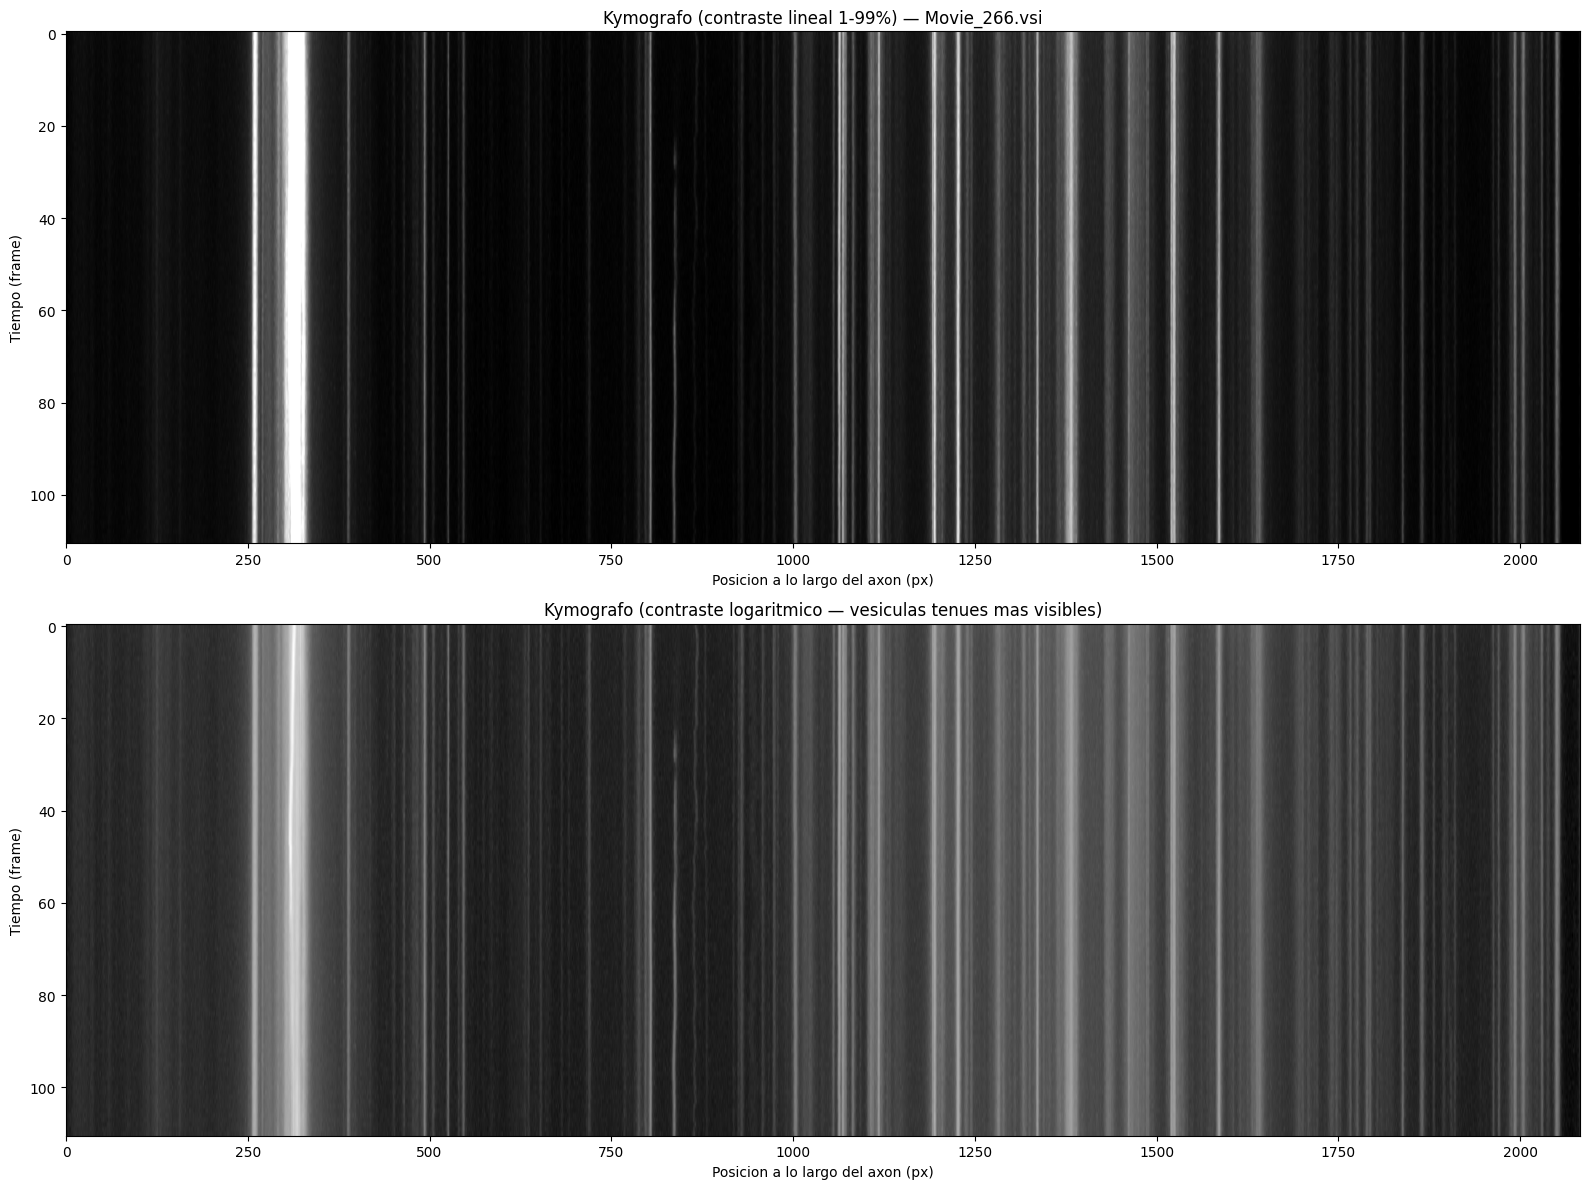

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Lineal
p1, p99 = np.percentile(kymo, [1, 99])
axes[0].imshow(kymo, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
axes[0].set_title(f"Kymografo (contraste lineal 1-99%) — {VIDEO.name}")
axes[0].set_xlabel("Posicion a lo largo del axon (px)")
axes[0].set_ylabel("Tiempo (frame)")

# Logaritmico
axes[1].imshow(np.log1p(kymo), cmap="gray", aspect="auto")
axes[1].set_title("Kymografo (contraste logaritmico — vesiculas tenues mas visibles)")
axes[1].set_xlabel("Posicion a lo largo del axon (px)")
axes[1].set_ylabel("Tiempo (frame)")

plt.tight_layout()
plt.show()

### Cómo leer el kymógrafo

Mirá la imagen de arriba. Vas a ver:

- **Líneas verticales** (paralelas al eje Y): vesículas/agregados estáticos. Quedan en la misma posición todo el video.
- **Líneas diagonales hacia la derecha** ↘: vesículas en transporte **anterógrado** (axón → terminal sináptico).
- **Líneas diagonales hacia la izquierda** ↙: vesículas en transporte **retrógrado** (terminal → soma).
- **Líneas con "escalones" o pausas**: vesículas que se mueven, se detienen, vuelven a moverse. Muy común.
- **La inclinación de cada línea = velocidad**. Casi vertical = lento; más diagonal = más rápido.

Esto es lo que el lab analiza manualmente en ImageJ con `Multi Kymograph` o `KymographBuilder`.


---

## Comparación con el kymógrafo del lab

El dataset incluye `Kymograph_674.tif` generado manualmente por el lab. Esa es nuestra **referencia ground truth**. Si nuestro generador produce algo similar, validamos la implementación.


Lab : shape=(111, 2081), dtype=uint8
Auto: shape=(111, 2083)


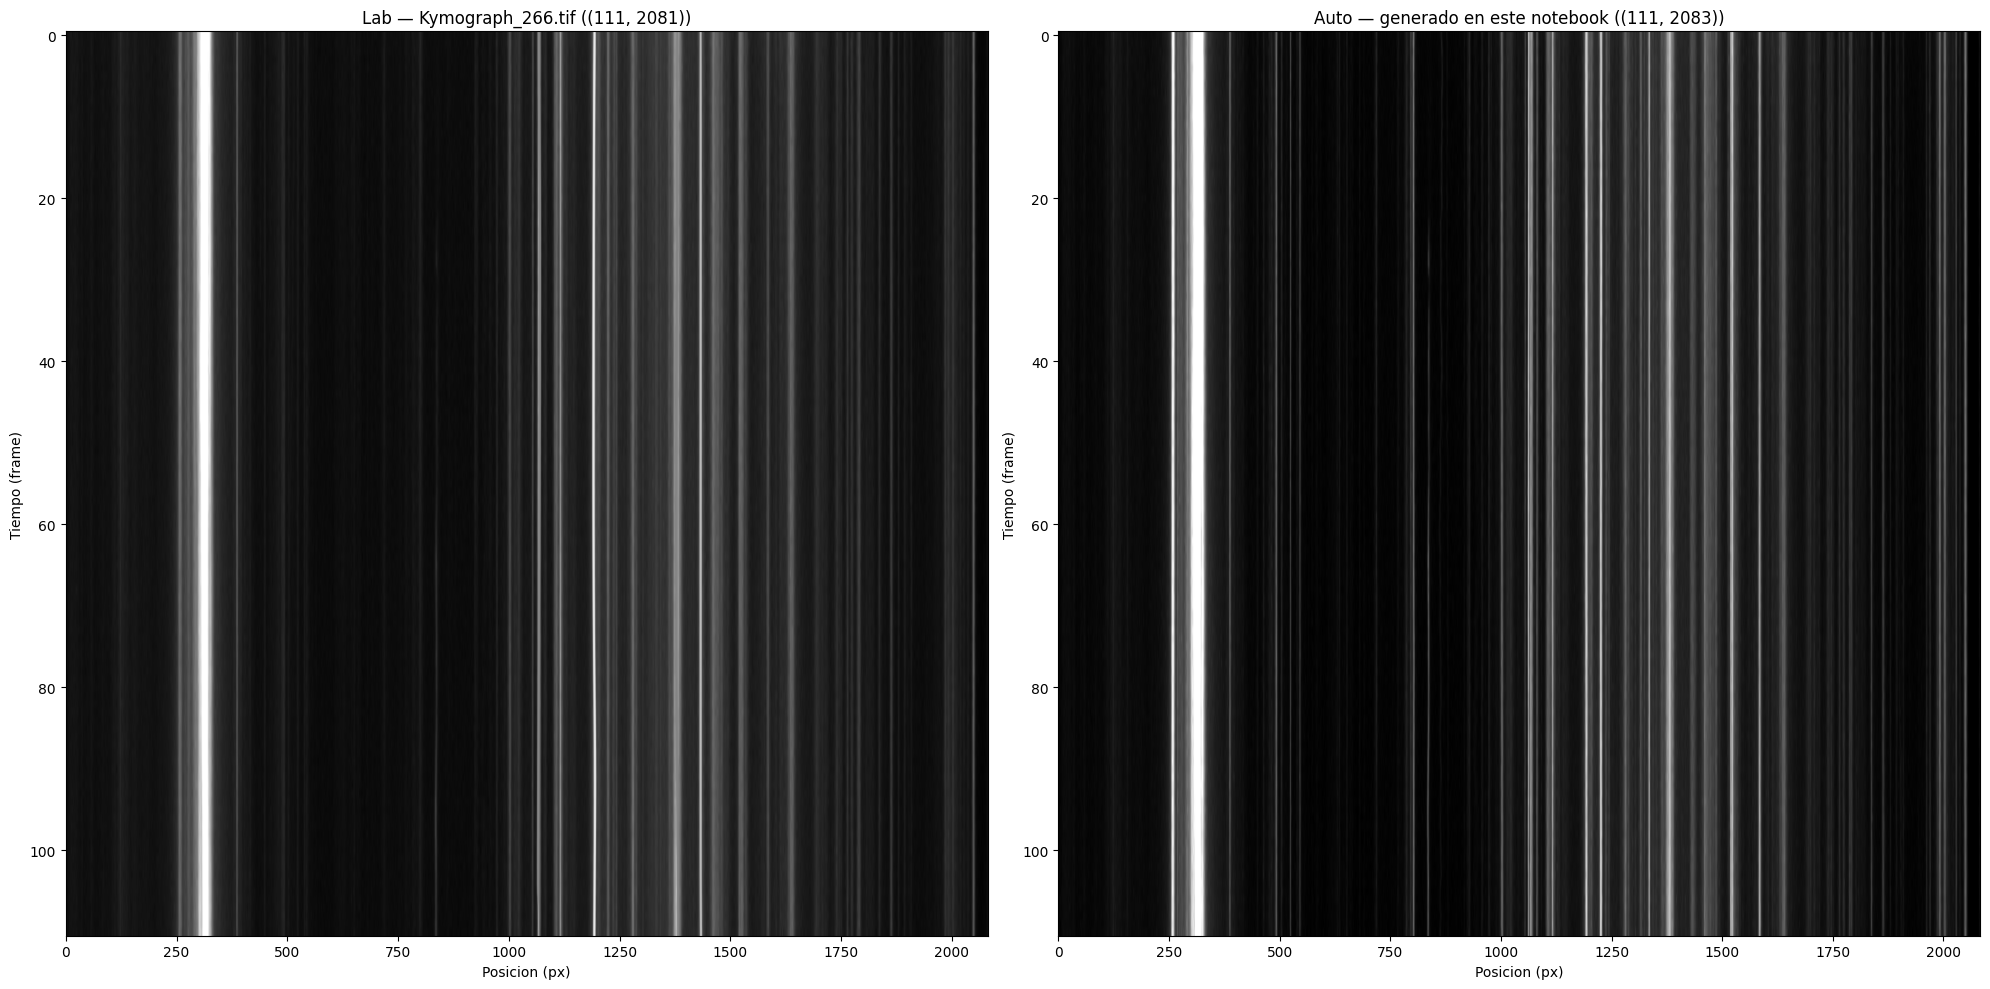

In [13]:
if KYMO_LAB.exists():
    kymo_lab = tifffile.imread(KYMO_LAB)
    print(f"Lab : shape={kymo_lab.shape}, dtype={kymo_lab.dtype}")
    print(f"Auto: shape={kymo.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    # Lab
    axes[0].imshow(kymo_lab, cmap="gray", aspect="auto")
    axes[0].set_title(f"Lab — {KYMO_LAB.name} ({kymo_lab.shape})")
    axes[0].set_xlabel("Posicion (px)")
    axes[0].set_ylabel("Tiempo (frame)")

    # Auto (log scale para que coincida visualmente)
    # axes[1].imshow(np.log1p(kymo), cmap="gray", aspect="auto")
    axes[1].imshow(kymo, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
    axes[1].set_title(f"Auto — generado en este notebook ({kymo.shape})")
    axes[1].set_xlabel("Posicion (px)")
    axes[1].set_ylabel("Tiempo (frame)")

    plt.tight_layout()
    plt.show()
else:
    print(f"No esta {KYMO_LAB.name} — saltamos la comparacion.")

### Qué buscar en la comparación

Las dos imágenes **no van a ser píxel-exactas** porque:

- El lab usa ImageJ que tiene su propio sampleo (probablemente `mean` perpendicular vs nuestro `max`).
- Hay redondeos distintos en la interpolación de la polilínea.
- El lab puede haber aplicado contraste / curvas distintas antes de exportar.

Pero las **trazas (las líneas) deberían coincidir en posición y pendiente**. Si las mismas vesículas son visibles en ambos como diagonales en los mismos lugares, validamos.


---

## Conversión de píxeles a unidades físicas

El kymógrafo está en píxeles × frames. Para análisis biológico necesitamos micrómetros × segundos.


In [12]:
dt = segundos_por_frame(VIDEO)  # s/frame de la sesion
if dt is None:
    print(
        f"Sesion no documentada para {VIDEO.name} — fijamos dt=0.2 s/frame como estimacion."
    )
    dt = 0.2

T, L = kymo.shape
tiempo_total_s = T * dt
longitud_um = res["longitud_um"]

print(f"Dimensiones fisicas del kymografo:")
print(f"  Eje espacial:  {L} px = {longitud_um:.1f} um (axon)")
print(f"  Eje temporal:  {T} frames = {tiempo_total_s:.1f} s")
print(f"")
print(f"Conversiones utiles:")
print(f"  1 px en eje X = {PIXEL_SIZE_UM:.3f} um")
print(f"  1 frame en eje Y = {dt:.3f} s")
print(f"  Velocidad: pendiente_px_por_frame × {PIXEL_SIZE_UM / dt:.3f} um/s")

Dimensiones fisicas del kymografo:
  Eje espacial:  2083 px = 222.7 um (axon)
  Eje temporal:  111 frames = 33.7 s

Conversiones utiles:
  1 px en eje X = 0.107 um
  1 frame en eje Y = 0.304 s
  Velocidad: pendiente_px_por_frame × 0.352 um/s


---

## Próximos pasos

Ahora que tenés el kymógrafo, el problema cambia: en lugar de **detectar puntos** en un video ruidoso, pasás a **detectar líneas** en una imagen 2D. Eso es mucho más fácil porque:

1. Las líneas son patrones coherentes que el ruido no produce.
2. Hay décadas de técnicas para detección de líneas (Hough transform, ridge detection, esqueletización).
3. Existen modelos específicos para esto en biología, ej. **KymoButler** (red neuronal entrenada en kymógrafos de transporte axonal).

Direcciones posibles:

1. **Hough transform** sobre el kymógrafo → líneas con pendientes (velocidades) y longitudes (cuánto tiempo se mueve cada vesícula).
2. **Ridge detection** (`skimage.filters.frangi` o `hessian`) → resalta estructuras lineales antes de detectarlas.
3. **Detección manual / etiquetado** en el kymógrafo (en vez de en los frames) — mucho más fácil y rápido para un humano, perfecto para entrenar un modelo.
4. **KymoButler** ([repo](https://github.com/MaxJakobs/KymoButler)) — está específicamente entrenado para este caso de uso. Vale la pena probarlo.

5. **Validar contra los xlsx del lab**: las hojas `Single Kymo` y `Part stats` tienen velocidades por partícula ya analizadas. Si extraés trazas y medís pendientes, podés calcular precision/recall directos contra ese ground truth.
